In [1]:
import sys
original_sys_path = sys.path.copy()
sys.path.append('../')
from utils_models import *

dq.set_device('cpu')
import warnings
warnings.filterwarnings("ignore")

In [2]:
solver = dq.solver.Tsit5(
                    rtol= 1e-06,
                    atol= 1e-06,
                    safety_factor= 0.9,
                    min_factor= 0.2,
                    max_factor = 5.0,
                    max_steps = int(1e4*1000),
                )

n_lvls_fluxonium = 20
n_lvls_transmon = 4


Ej_f = 2.7
Ec_f = 0.6
El_f = 0.13
qsf = qs.Fluxonium.create(
    n_lvls_fluxonium,
    {"Ej": Ej_f, "Ec": Ec_f, "El": El_f, "phi_ext": 0.0},
    N_pre_diag=100,
    use_linear = False
    )

g_tf = 0.2
Ec_t = 0.2

t_rise = 30

truncated_dim = 80 # will include 7,1
def truncate(data: jnp.array):
    return data[:,:]

tot_dim = truncated_dim

In [3]:


pulse_length = 2.47029937e+02 
Ej_t = 3.40890048e+01
amp_with_2pi = 9.13069185e-03

t_tot = t_rise + pulse_length
tlist = jnp.linspace(0,t_tot,int(t_tot))

qst = MyTransmon.create(
    N = n_lvls_transmon,
    params = {"Ej": Ej_t, "Ec": Ec_t,"ng":0.0},
    N_max_charge=10
    )

devices = [qsf, qst]
f_indx = 0
t_indx = 1
Ns = [device.N for device in devices]
fn = qs.promote(qsf.ops["n"], f_indx, Ns)
tn = qs.promote(qst.ops['n'], t_indx, Ns)

g_tf = 0.2
system = qs.System.create(devices, couplings=[
    g_tf *  fn @ tn
    ])
system.params["g_tf"] = g_tf
system_evals_sorted, system_evecs_sorted, product_indices_sorted_by_eval = calculate_eig(Ns, system.get_H())
driven_op = transform_op_into_dressed_basis_jax(tn, system_evecs_sorted.T)

system_evals_in_product_indices, system_evecs_in_product_indices = system.calculate_eig_linear()
w_d = system_evals_in_product_indices[0,1] - system_evals_in_product_indices[0,0]
pulse_shape_args={
    'w_d': w_d,
    'amp': amp_with_2pi/(2*jnp.pi),
    't_rise': t_rise,
    't_square': pulse_length - t_rise
}      

def _H(t):
    _H =  2 * jnp.pi *truncate(jnp.diag(system_evals_sorted))
    _H += truncate(driven_op) * square_pulse_with_rise_fall(t, pulse_shape_args)
    return _H 
H =  dq.timecallable(_H)

psi0_list = [truncate(dq.basis(tot_dim,find_closest_dressed_index(l*qst.N, product_indices_sorted_by_eval)))
                    for l in [0,1,2]] #00,10,20

e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(truncate(dq.basis_dm(math.prod(Ns),  find_closest_dressed_index(ql*qst.N+tl, product_indices_sorted_by_eval))))

result = dq.sesolve(
            H = H,
            psi0 = psi0_list,
            tsave = tlist,
            solver = solver,
            exp_ops = e_ops
            )

(-1e-05, 0.0001)

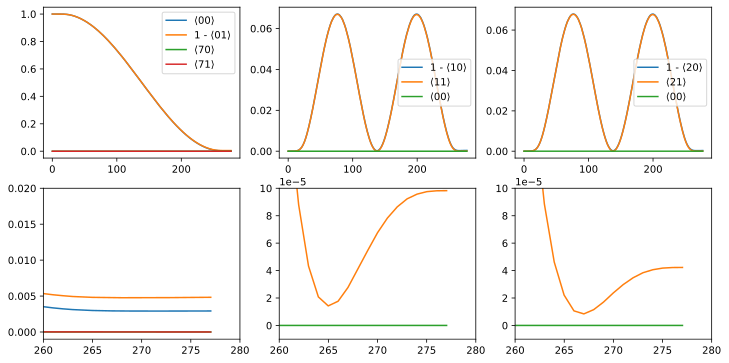

In [3]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1),(7,0),(7,1)],
                        [(1,0),(1,1),(0,0)],
                        [(2,0),(2,1),(0,0)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,result.expects[col][i],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - result.expects[col][i],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-3,2e-2)
axes[1,1].set_ylim(-1e-5,1e-4)
axes[1,2].set_ylim(-1e-5,1e-4)


(-1e-05, 0.0001)

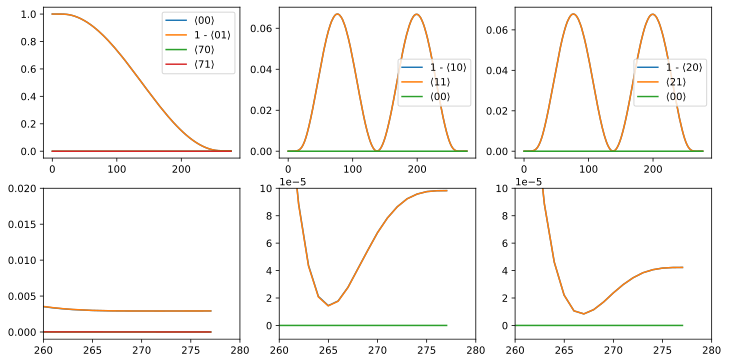

In [4]:
rhos = dq.todm(result.states)
traces = jnp.expand_dims(dq.trace(rhos).real, axis=(-2, -1))
rhos = rhos / traces

expects = dq.expect(O = jnp.array(e_ops),
                    x = rhos)


colors = ['green','red','darkorange']
fig,axes = plt.subplots(2,3,figsize = (12,6))
for col, levels_list in zip([0,1,2],
                    [
                        [(0,0),(0,1),(7,0),(7,1)],
                        [(1,0),(1,1),(0,0)],
                        [(2,0),(2,1),(0,0)]
                    ]):
    for row in [0,1]:
        for (ql,tl) in levels_list:
            i = ql*4+tl
            if (ql,tl) not in [(0,1), (1,0),(2,0)]:
                axes[row, col].plot(tlist,expects[i][col],label = rf"$\langle{ql}{tl}\rangle$")
            else:
                axes[row, col].plot(tlist,1 - expects[i][col],label = rf"1 - $\langle{ql}{tl}\rangle$")
    axes[0,col].legend()
    # axes[1,col].axvline(x=270, color='b', linestyle='--')
    axes[1,col].set_xlim(260,280)

axes[1,0].set_ylim(-1e-3,2e-2)
axes[1,1].set_ylim(-1e-5,1e-4)
axes[1,2].set_ylim(-1e-5,1e-4)
